In [1]:
## Importing Libraries

import os
import copy
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


from pathlib import Path
from tqdm.notebook import tqdm
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision import models

from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from torchvision.models.detection import (fasterrcnn_resnet50_fpn)
from torchvision.models.detection.faster_rcnn import (FastRCNNPredictor)

from torchvision.ops import box_iou

from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)



print("Libraries Loaded Successfully.")

Libraries Loaded Successfully.


In [2]:
## Setting Training Device & Paths

device = torch.device("cuda")
print(f"Device : {device}")

ROOT_DIR = Path.cwd().parent

DATASET_DIR = ROOT_DIR / "datasets" / "processed_dataset"

TRAIN_DIR = DATASET_DIR / "images" / "train"
VAL_DIR = DATASET_DIR / "images" / "val"
TEST_DIR = DATASET_DIR / "images" / "test"

MODELS_DIR = ROOT_DIR / "models"/ "FasterRCNN"
MODELS_DIR.mkdir(exist_ok=True)

print("Dataset Loaded.")

Device : cuda
Dataset Loaded.


In [3]:
## Applying Image Tranformers

train_transform = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor()])

val_test_transform = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.ToTensor()])

print("Transforms Ready.")

Transforms Ready.


In [ ]:
## Creating Dataset Class

class WeedDataset(Dataset):
    def __init__(self, image_dir, label_dir, transform=None):
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.transform = transform

        self.images = sorted(list(image_dir.glob("*")))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = self.images[idx]
        label_path = (self.label_dir / f"{image_path.stem}.txt")
        image = Image.open(image_path).convert("RGB")

        width, height = image.size

        boxes = []
        labels = []

        with open(label_path, "r") as f:
            lines = f.readlines()

            for line in lines:
                cls, x, y, w, h = map(float, line.strip().split())

                xmin = (x - w/2) * width
                ymin = (y - h/2) * height

                xmax = (x + w/2) * width
                ymax = (y + h/2) * height

                xmin = xmin * (640 / width)
                xmax = xmax * (640 / width)

                ymin = ymin * (640 / height)
                ymax = ymax * (640 / height)

                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(int(cls) + 1)

        if self.transform:
            image = self.transform(image)

        target = {
                "boxes": torch.tensor(
                boxes,
                dtype=torch.float32),

                "labels": torch.tensor(
                labels,
                dtype=torch.int64)}

        return image, target

In [5]:
## Creating Datasets

train_dataset = WeedDataset(TRAIN_DIR, DATASET_DIR / "labels" / "train", transform=train_transform)
val_dataset = WeedDataset(VAL_DIR, DATASET_DIR / "labels" / "val", transform=val_test_transform)
test_dataset = WeedDataset(TEST_DIR, DATASET_DIR / "labels" / "test", transform=val_test_transform)

print("Train :", len(train_dataset))
print("Val   :", len(val_dataset))
print("Test  :", len(test_dataset))

Train : 3948
Val   : 846
Test  : 847


In [6]:
## Creating DataLoaders

def collate_fn(batch):
    return tuple(zip(*batch))

BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    collate_fn=collate_fn)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=collate_fn)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True,
    collate_fn=collate_fn)

In [ ]:
## Inspecting Batch

images, targets = next(iter(train_loader))

print("Images in Batch :", len(images))
print("Boxes Shape :", targets[0]["boxes"].shape)
print("Labels Shape :", targets[0]["labels"].shape)


print(images[0].shape)
print(targets[0]["boxes"][:5])

Images in Batch : 4
Boxes Shape : torch.Size([1, 4])
Labels Shape : torch.Size([1])


In [8]:
## Loading ResNet50 Model

model = fasterrcnn_resnet50_fpn(weights="DEFAULT")

in_features = (model.roi_heads.box_predictor.cls_score.in_features)
model.roi_heads.box_predictor = (FastRCNNPredictor(in_features, 13))

model = model.to(device)
print("Faster R-CNN Ready.")

Faster R-CNN Ready.


In [9]:
## Seeting Optimizer

optimizer = optim.Adam(model.parameters(), lr=0.0001)

print("Optimizer Ready.")

Optimizer Ready.


In [10]:
## Training Function

def train_one_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0

    progress_bar = tqdm(loader, total=len(loader), desc="Training", leave=False)

    for images, targets in progress_bar:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        total_loss = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()
        progress_bar.set_postfix(loss=f"{total_loss.item():.4f}")

    epoch_loss = (running_loss / len(loader))

    return epoch_loss

In [11]:
## Validation Function

def validate(model, loader):
    model.train()

    running_loss = 0

    with torch.no_grad():
        for images, targets in loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            total_loss = sum(loss for loss in loss_dict.values())

            running_loss += (total_loss.item())

    epoch_loss = (running_loss / len(loader))

    return epoch_loss

In [12]:
## Checkpoint Helpers

CHECKPOINT_PATH = MODELS_DIR / "faster_rcnn_checkpoint.pth"
BEST_MODEL_PATH = MODELS_DIR / "best_faster_rcnn_model.pth"

def save_checkpoint(epoch, model, optimizer, best_acc, history):
    torch.save({"epoch": epoch, "model_state_dict": model.state_dict(), "optimizer_state_dict": optimizer.state_dict(), "best_acc": best_acc, "history": history }, CHECKPOINT_PATH)

def load_checkpoint():
    if CHECKPOINT_PATH.exists():
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

        print(
            f"Resuming from Epoch "
            f"{checkpoint['epoch'] + 1}")

        return (checkpoint["epoch"] + 1, checkpoint["best_acc"], checkpoint["history"])

    return 0, float("inf"), {"train_loss": [], "val_loss": []}

In [13]:
## Initializing Training 

NUM_EPOCHS = 30

start_epoch, best_loss, history = load_checkpoint()

print(f"Starting Epoch : {start_epoch}")
print(f"Best Accuracy  : {best_loss:.4f}")

Resuming from Epoch 1
Starting Epoch : 1
Best Accuracy  : 23.8218


In [14]:
## Training Loop

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")

    train_loss = train_one_epoch(model, train_loader, optimizer)
    val_loss = validate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss

        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print("Best Model Saved.")

    save_checkpoint(epoch, model, optimizer, best_loss, history)

print("Training Complete.")


Epoch [2/30]


Training:   0%|          | 0/987 [00:00<?, ?it/s]

Train Loss: 22.5638 | Val Loss: 21.8941
Best Model Saved.

Epoch [3/30]


Training:   0%|          | 0/987 [00:00<?, ?it/s]

Train Loss: 20.8618 | Val Loss: 21.9541

Epoch [4/30]


...

Train Loss: 17.0217 | Val Loss: 19.4731

Epoch [29/30]


Training:   0%|          | 0/987 [00:00<?, ?it/s]

Train Loss: 16.9752 | Val Loss: 18.6608
Best Model Saved.

Epoch [30/30]


Training:   0%|          | 0/987 [00:00<?, ?it/s]

Train Loss: 16.7439 | Val Loss: 18.7361
Training Complete.


In [15]:
## Loading Best Model

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.eval()

print("Best Model Loaded.")

Best Model Loaded.


Displaying Image 2
Detections : 7


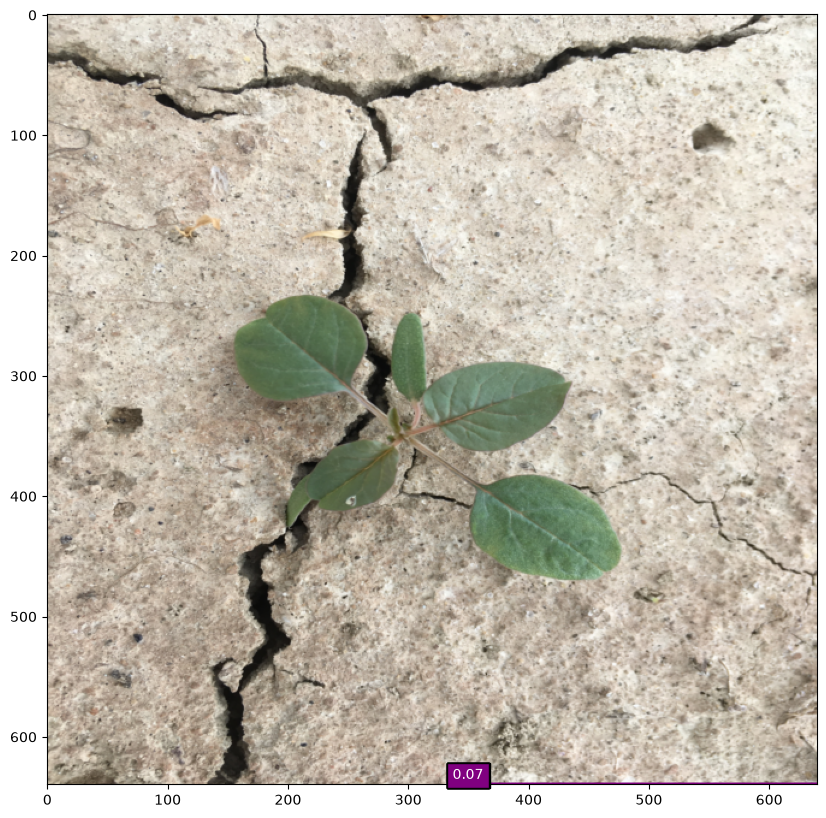

In [41]:
## Evaluations

import matplotlib.pyplot as plt
import matplotlib.patches as patches

model.eval()

images, targets = next(iter(test_loader))

found = False

for idx in range(len(images)):

    image = images[idx].to(device)

    with torch.no_grad():
        prediction = model([image])[0]

    if len(prediction["boxes"]) > 0:

        print(f"Displaying Image {idx}")
        print(f"Detections : {len(prediction['boxes'])}")

        img = image.cpu().permute(1, 2, 0).numpy()

        fig, ax = plt.subplots(figsize=(10,10))
        ax.imshow(img)

        for box, score in zip(
            prediction["boxes"],
            prediction["scores"]
        ):

            if score > 0:

                x1, y1, x2, y2 = box.cpu().numpy()

                rect = patches.Rectangle(
                    (x1, y1),
                    x2 - x1,
                    y2 - y1,
                    fill=False,
                    edgecolor="purple",
                    linewidth=3
                )

                ax.add_patch(rect)

                ax.text(
                    x1,
                    y1 - 5,
                    f"{score:.2f}",
                    color="white",
                    fontsize=10,
                    bbox=dict(facecolor="purple")
                )

        plt.show()

        found = True
        break

if not found:
    print("No detections found in this batch.")

tensor([[ 707.9985, 1111.9994, 2308.0000, 2553.0000]])


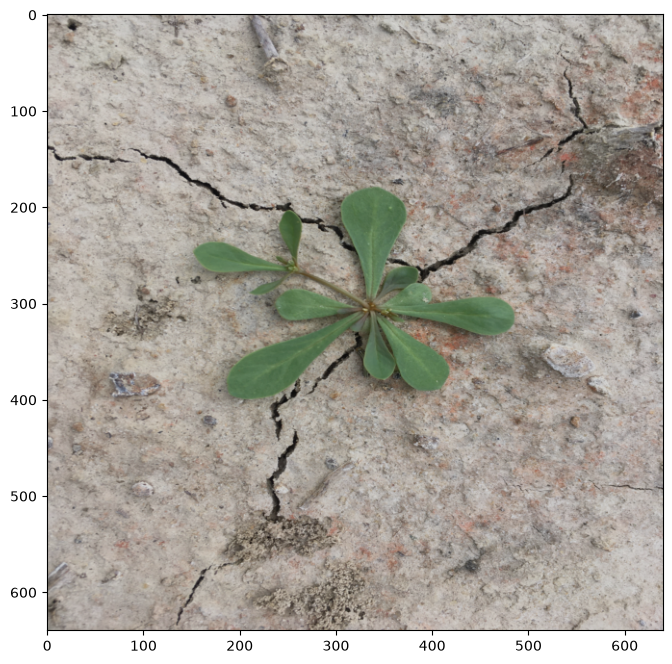

In [31]:
image, target = train_dataset[0]

print(target["boxes"])

img = image.permute(1,2,0).numpy()

fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(img)

for box in target["boxes"]:
    x1,y1,x2,y2 = box.numpy()

    rect = patches.Rectangle(
        (x1,y1),
        x2-x1,
        y2-y1,
        fill=False,
        edgecolor="red",
        linewidth=3
    )

    ax.add_patch(rect)

plt.show()

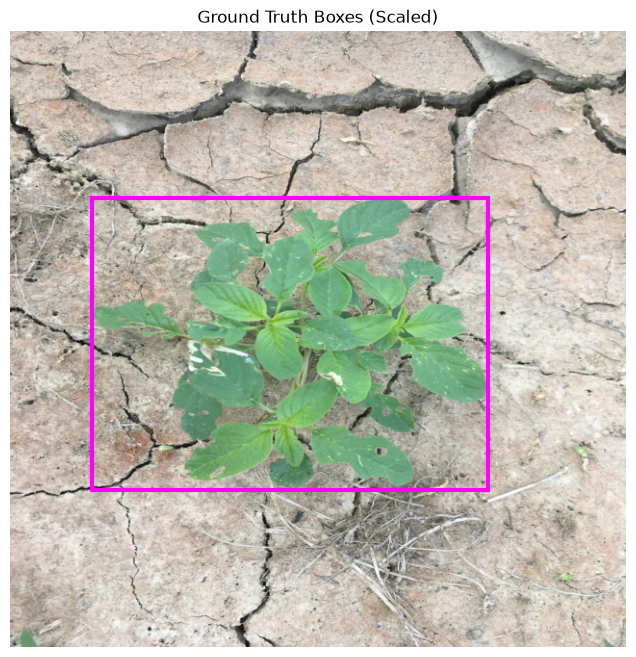

In [38]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

images, targets = next(iter(test_loader))

image = images[0]
target = targets[0]

img = image.permute(1, 2, 0).cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(img)

# Original image dimensions
ORIG_W = 3024
ORIG_H = 4032

# Current image dimensions
NEW_W = 640
NEW_H = 640

scale_x = NEW_W / ORIG_W
scale_y = NEW_H / ORIG_H

for box in target["boxes"]:

    x1, y1, x2, y2 = box.numpy()

    # Scale coordinates down to match resized image
    x1 *= scale_x
    x2 *= scale_x

    y1 *= scale_y
    y2 *= scale_y

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        fill=False,
        edgecolor="magenta",
        linewidth=3
    )

    ax.add_patch(rect)

plt.title("Ground Truth Boxes (Scaled)")
plt.axis("off")
plt.show()


Displaying Image 2
Detections : 7

Top 10 Scores:
tensor([0.2269, 0.1274, 0.1120, 0.1046, 0.0884, 0.0839, 0.0679],
       device='cuda:0')

Boxes Drawn : 7


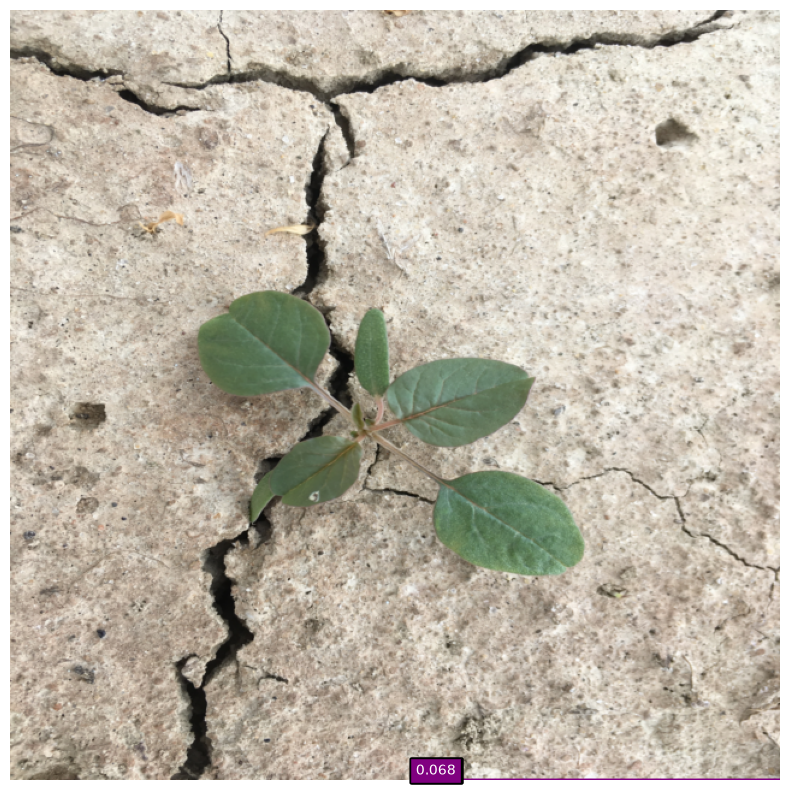

In [42]:
# %%
## Evaluations

import matplotlib.pyplot as plt
import matplotlib.patches as patches

model.eval()

images, targets = next(iter(test_loader))

found = False

for idx in range(len(images)):

    image = images[idx].to(device)

    with torch.no_grad():
        prediction = model([image])[0]

    if len(prediction["scores"]) > 0:

        print(f"\nDisplaying Image {idx}")
        print(f"Detections : {len(prediction['boxes'])}")

        print("\nTop 10 Scores:")
        print(prediction["scores"][:10])

        img = image.cpu().permute(1, 2, 0).numpy()

        fig, ax = plt.subplots(figsize=(10, 10))
        ax.imshow(img)

        boxes_drawn = 0

        for box, score in zip(
            prediction["boxes"],
            prediction["scores"]
        ):

            if score > 0.01:

                x1, y1, x2, y2 = box.cpu().numpy()

                rect = patches.Rectangle(
                    (x1, y1),
                    x2 - x1,
                    y2 - y1,
                    fill=False,
                    edgecolor="purple",
                    linewidth=3
                )

                ax.add_patch(rect)

                ax.text(
                    x1,
                    max(0, y1 - 5),
                    f"{score:.3f}",
                    color="white",
                    fontsize=10,
                    bbox=dict(facecolor="purple")
                )

                boxes_drawn += 1

        print(f"\nBoxes Drawn : {boxes_drawn}")

        plt.axis("off")
        plt.show()

        found = True
        break

if not found:
    print("No detections found in this batch.")

In [43]:
for i, (box, score) in enumerate(
    zip(prediction["boxes"], prediction["scores"])
):
    print(f"\nDetection {i+1}")
    print("Score:", score.item())
    print("Box:", box.cpu().numpy())


Detection 1
Score: 0.22692552208900452
Box: [336.99722 639.94855 640.      640.     ]

Detection 2
Score: 0.12743978202342987
Box: [337.17877 639.94855 639.8715  640.     ]

Detection 3
Score: 0.11196693778038025
Box: [336.99606 639.94855 639.9971  640.     ]

Detection 4
Score: 0.10457661747932434
Box: [337.01617 639.94855 639.9587  640.     ]

Detection 5
Score: 0.08835860341787338
Box: [337.0102  639.94855 640.      640.     ]

Detection 6
Score: 0.08387929946184158
Box: [336.96332 639.94855 639.94495 640.     ]

Detection 7
Score: 0.06789682805538177
Box: [336.80545 639.9486  639.77216 639.99994]
